In [219]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [220]:
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path("/content/drive/MyDrive/titanic.csv")

In [221]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, classification_report
X, y = load_iris(return_X_y=True)
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
titanic_data = pd.read_csv(base_path)

Tu z poprzedniego tygodnia przerabiam tabelę

In [222]:
titanic_data.drop(columns=['PassengerId','Ticket'], inplace=True)

In [223]:
titanic_data['HasCabin'] = titanic_data['Cabin'].apply(lambda x: '1' if pd.notnull(x) else '0')

In [224]:
titanic_data.drop(columns=['Cabin'], inplace=True)

In [225]:
titanic_data['Title'] = titanic_data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
titanic_data.drop(columns=['Name'], inplace=True)

In [226]:
titanic_data['Title'] = titanic_data['Title'].replace(['Mlle', 'Ms'], 'Miss')
titanic_data['Title'] = titanic_data['Title'].replace('Mme', 'Mrs')
inne = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
titanic_data['Title'] = titanic_data['Title'].replace(inne, 'Other')
titanic_data['Age'] = titanic_data.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
titanic_data['Fare'] = titanic_data.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))

In [227]:
titanic_data['Embarked'] = titanic_data['Embarked'].fillna('S')

In [228]:
titanic_data['Sex'] = titanic_data['Sex'].map({'female': 0, 'male': 1})
titanic_data = pd.get_dummies(titanic_data, columns=['Embarked', 'Title'], drop_first=False, dtype=int)

In [229]:
titanic_data['FamMem'] = titanic_data['SibSp'] + titanic_data['Parch']
titanic_data.drop(columns=['SibSp', 'Parch'], inplace=True)
titanic_data.head()

,Survived,Pclass,Sex,Age,Fare,HasCabin,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Other,FamMem
0,0,3,1,22.0,7.2500,0,0,0,1,0,0,1,0,0,1
1,1,1,0,38.0,71.2833,1,1,0,0,0,0,0,1,0,1
2,1,3,0,26.0,7.9250,0,0,0,1,0,1,0,0,0,0
3,1,1,0,35.0,53.1000,1,0,0,1,0,0,0,1,0,1
4,0,3,1,35.0,8.0500,0,0,0,1,0,0,1,0,0,0


- Usunięcie tabel PassengerId, Ticket - nie odpowiadają żadnej cesze pasażera, która wpływałaby na przeżycie
- Cabin miało duże braki, więc zostało zastąpione HasCabin
- Age uzupełnione wg mediany z poszczególnych tytułów, Embarked uzupełnione dominantą
- Fare uzupełnione wg mediany w konkretnej klasie
- SibSp, Parch dodane do siebie dają FamMem

Teraz zajmujemy się zadaniem

Standaryzacja danych powinna być przeprowadzona na modelach odległościowych (np. KNN), aby wartości z dużym zakresem takie jak np. cena biletów Fare nie dominowały nad cechami kodowanymi zero-jedynkowo

Żeby nie przetrenować modelu, należy ograniczyć głębokość drzewa (max_depth), wymusić minimalną liczbę próbek do podziału (min_samples_split) albo wybrać odpowiednią liczbę sąsiadów w KNN (n_neighbors). Warto też użyć kroswalidacji, w celu zniwelowaniu losowości, z którą wybierana jest 1/5 zbioru danych jako danych testowych

Wynik można uznać za dobry, np. gdy jest wyraźnie lepszy od DummyClassifiera

In [230]:
X = titanic_data.drop(columns=['Survived'])
y = titanic_data['Survived']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [231]:
def evaluate_model(model, name="Model"):
  model.fit(X_train, y_train)
  pred = model.predict(X_test)
  prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else pred
  print(f"accuracy:  {accuracy_score(y_test, pred):.4f}")
  print(f"precision: {precision_score(y_test, pred):.4f}")
  print(f"recall:    {recall_score(y_test, pred):.4f}")
  print(f"f1-score:  {f1_score(y_test, pred):.4f}")

- f1-score pozwala na zbalansowanie zbioru, w którym większość osób nie przeżyła, jest średnią harmoniczną z precision i recall
- accuracy pokazuje ułamek prawidłowo sklasyfikowanych pasażerów
- precision liczy odsetek pasażerów uznanych za ocalałych faktycznie przeżyło
- recall sprawdza jaki procent pasażerów, którzy przeżyli, została oznaczona przez model jako ocaleli

In [237]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.8, shuffle=True)
model = DummyClassifier(strategy = 'uniform')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.59      0.47      0.52       106
           1       0.40      0.52      0.46        73

    accuracy                           0.49       179
   macro avg       0.50      0.50      0.49       179
weighted avg       0.51      0.49      0.50       179



array([[50, 56],
       [35, 38]])

Powyżej, strategy = 'uniform', więc model losowo przypisuje wartości 0 i 1 -> accuracy to około 50%. Poniżej, do każdego przewidywania przypisuje wartość najczęście występującą w zbiorze treningowym, czyli w naszym przypadku 0

In [232]:
dummy = DummyClassifier(strategy='most_frequent')
evaluate_model(dummy, "baseline")

accuracy:  0.6145
precision: 0.0000
recall:    0.0000
f1-score:  0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [233]:
from sklearn.model_selection import cross_val_score

model = DecisionTreeClassifier(max_depth=3)
wyniki = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print(wyniki)
print(f"srednia: {wyniki.mean():.3f}  odchylenie: {wyniki.std():.3f}")

[0.8547486  0.80898876 0.83146067 0.78089888 0.85955056]
srednia: 0.827  odchylenie: 0.029


In [ ]:
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)


              precision    recall  f1-score   support

           0       0.84      0.87      0.85       106
           1       0.80      0.75      0.77        73

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



array([[92, 14],
       [18, 55]])

Na górze na stałe wpisana jest wartość, dla której podane są dalsze procenty dokładności, natomiast poniżej na wykresie widać zilustrowany wskaźnik f1 w stosunku do wybranej głębokości drzewa


Najlepsze parametry Drzewa: {'max_depth': 3, 'min_samples_split': 2}
accuracy:  0.8324
precision: 0.8197
recall:    0.7246
f1-score:  0.7692


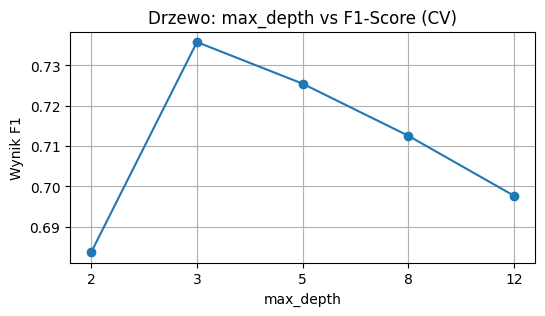

In [234]:
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {'max_depth':[2,3,5,8,12], 'min_samples_split':[2, 5, 10]}, cv=5, scoring = 'f1'
)
dt_grid.fit(X_train, y_train)

print(f"\nNajlepsze parametry Drzewa: {dt_grid.best_params_}")
evaluate_model(dt_grid.best_estimator_, "Najlepsze Drzewo Decyzyjne")

dt_res = pd.DataFrame(dt_grid.cv_results_)
dt_sub = dt_res[dt_res['param_min_samples_split'] == 5]
plt.figure(figsize=(6, 3))
plt.plot(dt_sub['param_max_depth'].astype(str), dt_sub['mean_test_score'], marker='o')
plt.title("Drzewo: max_depth vs F1-Score (CV)")
plt.xlabel("max_depth")
plt.ylabel("Wynik F1")
plt.grid(True)
plt.show()

Dla drzewa, hiperparametry to max_depth i min_samples_split. Wykres pokazuje, że z zadanych wartości (2, 3, 5, 8 10) najlepsze jest wzięcie maksymalnej głębokości 3, ponieważ dalej wynik f1 zaczyna spadać z powodu overfittingu, a z kolei dla głębokości 2, model byłby niedouczony. Minimalna liczba próbek do podziału również zapobiega przeuczeniu (gdy jest za mała) i niedouczeniu (za duża). Zapobiega temu, żeby model tworzył bardzo specyficzne ścieżki na podstawie konkretnych pasażerów.

In [235]:
from sklearn.neighbors import KNeighborsClassifier

for nazwa, m in [
    ("Dummy      ", DummyClassifier(strategy='uniform')),
    ("Drzewo     ", DecisionTreeClassifier(max_depth=3)),
    ("KNN (k=5)  ", KNeighborsClassifier(n_neighbors=5)),
]:
    w = cross_val_score(m, X, y, cv=5)
    print(f"{nazwa} {w.mean():.3f} +/- {w.std():.3f}")

Dummy       0.513 +/- 0.022
Drzewo      0.827 +/- 0.029
KNN (k=5)   0.709 +/- 0.045


Powyżej "na sztywno" wpisana jest ilość branych pod uwagę sąsiadów, natomiast poniżej najlepsza wartość wybierana jest na podstawie wagi i najlepszego wariantu KNN.

Najlepsze parametry KNN: {'n_neighbors': 11, 'weights': 'distance'}
accuracy:  0.6927
precision: 0.6029
recall:    0.5942
f1-score:  0.5985


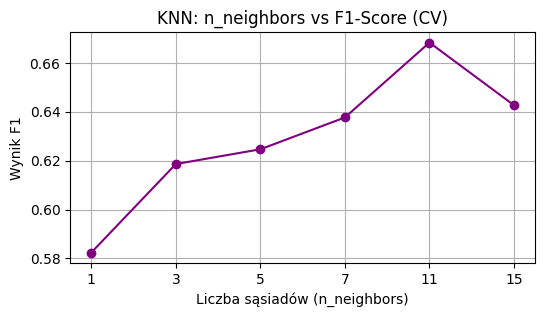

In [236]:
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': [1, 3, 5, 7, 11, 15], 'weights': ['uniform', 'distance']},
    cv=5, scoring='f1'
)
knn_grid.fit(X_train, y_train)

print(f"Najlepsze parametry KNN: {knn_grid.best_params_}")
evaluate_model(knn_grid.best_estimator_, "Najlepszy KNN")

knn_res = pd.DataFrame(knn_grid.cv_results_)
knn_sub = knn_res[knn_res['param_weights'] == 'distance']

plt.figure(figsize=(6, 3))
plt.plot(knn_sub['param_n_neighbors'].astype(str), knn_sub['mean_test_score'], marker='o', color='purple')
plt.title("KNN: n_neighbors vs F1-Score (CV)")
plt.xlabel("Liczba sąsiadów (n_neighbors)")
plt.ylabel("Wynik F1")
plt.grid(True)
plt.show()

Po kroswalidacji lepszy wynik daje uznanie parametru weigths jako 'distance', który zwiększa wpływ bliższych sąsiadów. Optymalna liczba sąsiadów wynosi wtedy 11. Powyżej tej liczby będziemy mieli ponownie doczynienia z underfittingiem, zbyt różni pasażerowie będą brani pod uwagę przy ocenianiu przeżycia.